In [ ]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [ ]:
# MSE vs Warmups:
rosen_trace_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Paper_Distribution/Rosen_trace_constrained.pkl"
rosen_trace_c_df = pd.read_pickle(rosen_trace_c_path)

rosen_trace_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Paper_Distribution/Rosen_trace_naive.pkl"
rosen_trace_n_df = pd.read_pickle(rosen_trace_n_path)

In [ ]:
rosen_trace_c_df.head()

,Warmup Length,Iteration,Final Position,Initial Position
0,10,0,"[[6.175023, -0.92373776], [6.65174, -0.0662704...","[[12.040142, -7.0633717], [-5.4817224, -9.7136..."
1,10,0,"[[6.175023, -0.92373776], [6.65174, -0.0662704...","[[12.040142, -7.0633717], [-5.4817224, -9.7136..."
2,10,1,"[[-0.71097255, -2.5081317], [-1.5447606, -1.44...","[[-22.424557, -18.356806], [4.0554423, -1.5355..."
3,10,0,"[[6.175023, -0.92373776], [6.65174, -0.0662704...","[[12.040142, -7.0633717], [-5.4817224, -9.7136..."
4,10,1,"[[-0.71097255, -2.5081317], [-1.5447606, -1.44...","[[-22.424557, -18.356806], [4.0554423, -1.5355..."


In [ ]:
rosen_trace_c_df["Final Position"][0]

array([[ 6.175023  , -0.92373776],
       [ 6.65174   , -0.06627041],
       [ 5.588736  , -1.9802873 ],
       ...,
       [ 7.8723345 , -0.85717314],
       [11.73138   ,  0.49087793],
       [ 7.829963  , -1.1311209 ]], dtype=float32)

In [ ]:
rosen_trace_c_df["Final Position"][0][-1]

array([ 7.829963 , -1.1311209], dtype=float32)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def potential(theta1, theta2):
    """
    Negative log density up to an additive constant for:

        theta1 ~ Normal(0, 10)
        theta2 | theta1 ~ Normal(
            0.03 * (theta1^2 - 100),
            1
        )
    """

    conditional_mean = 0.03 * (theta1**2 - 100)

    return (
        0.5 * (theta1 / 10)**2
        + 0.5 * (theta2 - conditional_mean)**2
    )


def plot_rosenbrock_final_positions(rosen_trace_c_df, iteration):

    warmup_lengths = [10, 20, 30, 40, 50, 100, 200, 500, 1000]

    # --------------------------------------------------
    # Create contour grid
    # --------------------------------------------------

    theta1 = np.linspace(-40, 40, 500)
    theta2 = np.linspace(-15, 40, 500)

    T1, T2 = np.meshgrid(theta1, theta2)

    Z = potential(T1, T2)

    # Common contour levels across all panels
    levels = np.linspace(0, 20, 20)

    # --------------------------------------------------
    # Create 3x3 subplot grid
    # --------------------------------------------------

    fig, axes = plt.subplots(
        3, 3,
        figsize=(15, 12),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    # --------------------------------------------------
    # Plot each warmup length
    # --------------------------------------------------

    for ax, warmup in zip(axes, warmup_lengths):

        # Select corresponding row
        row = rosen_trace_c_df[
            (rosen_trace_c_df["Warmup Length"] == warmup)
            &
            (rosen_trace_c_df["Iteration"] == iteration)
        ]

        # Draw contour lines only
        ax.contour(
            T1,
            T2,
            Z,
            levels=levels,
            colors="black",
            linewidths=0.8
        )

        if row.empty:
            ax.set_title(
                f"Warmup = {warmup}\nNo data"
            )
            continue

        # Directly retrieve final positions
        final_positions = row.iloc[0]["Final Position"]

        # Overlay MCMC positions
        ax.scatter(
            final_positions[:, 0],
            final_positions[:, 1],
            s=10,
            alpha=0.6,
            color="red"
        )

        ax.set_title(
            f"Warmup Length = {warmup}"
        )

        ax.grid(
            True,
            linestyle="--",
            alpha=0.3
        )

    # --------------------------------------------------
    # Axis labels
    # --------------------------------------------------

    for ax in axes[6:]:
        ax.set_xlabel(r"$\theta_1$")

    for ax in axes[::3]:
        ax.set_ylabel(r"$\theta_2$")

    fig.suptitle(
        f"Final MCMC Positions by Warmup Length\nIteration = {iteration}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

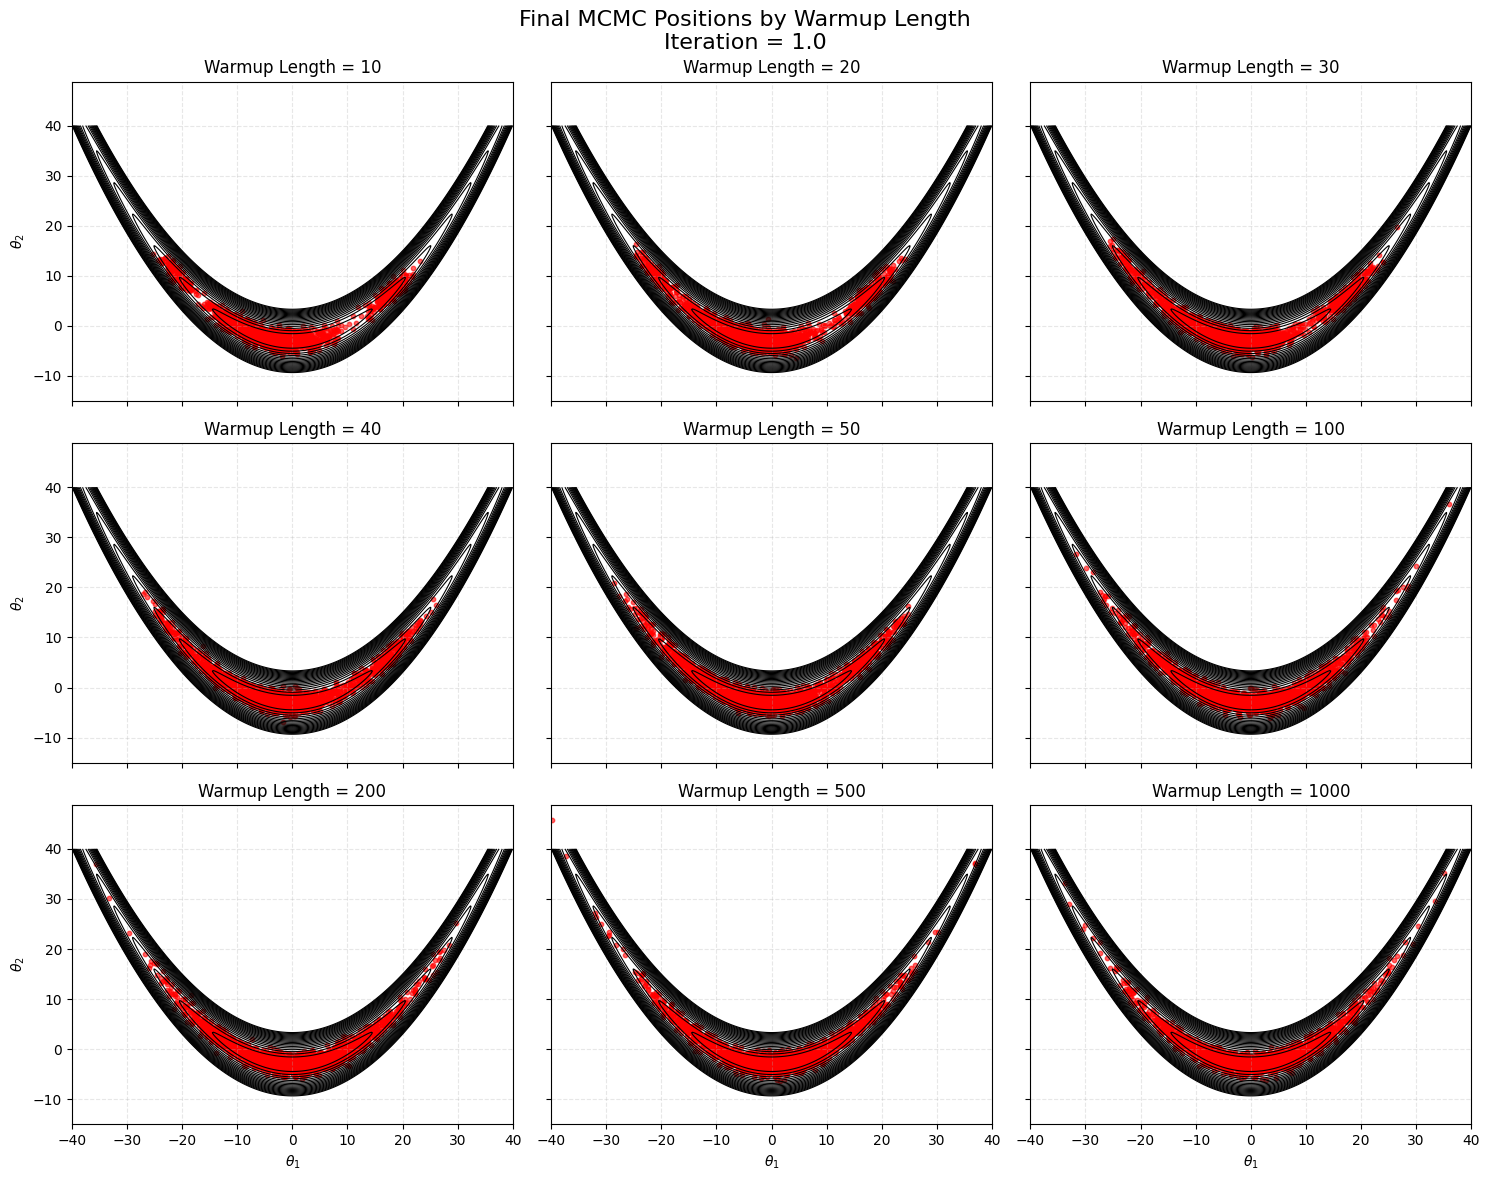

In [ ]:
plot_rosenbrock_final_positions(
    rosen_trace_c_df,
    iteration=1.0
)

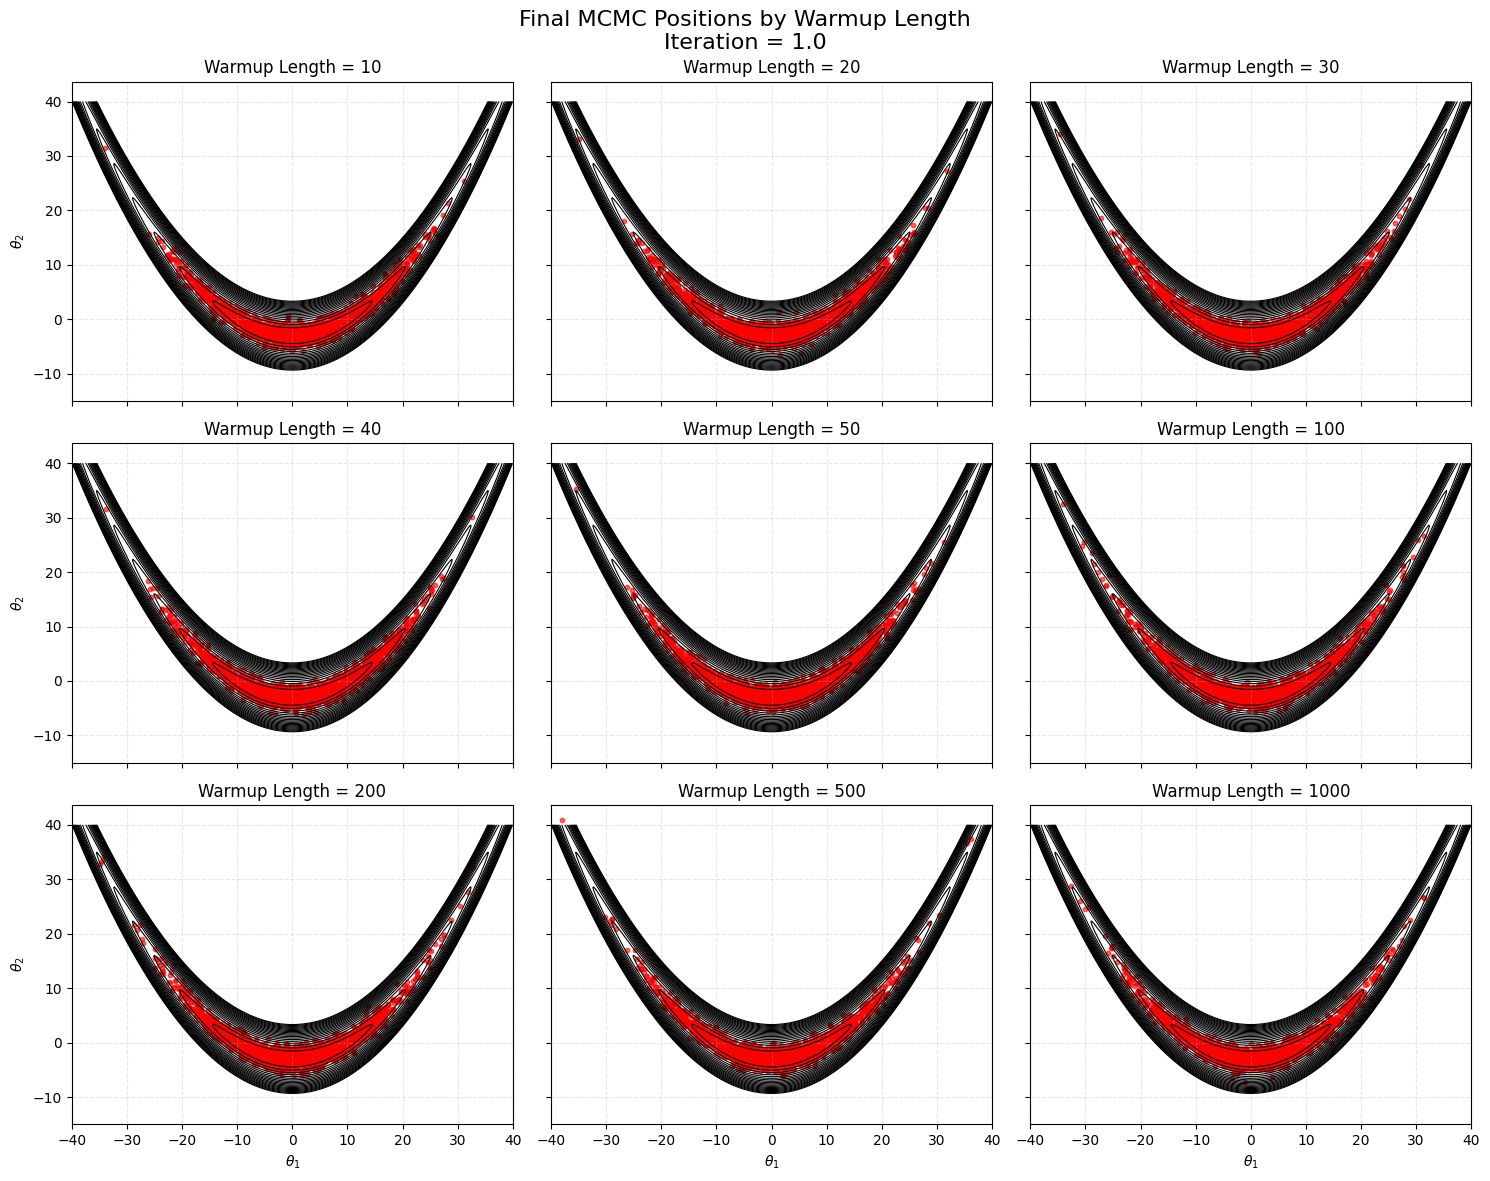

In [ ]:
plot_rosenbrock_final_positions(
    rosen_trace_n_df,
    iteration=1.0
)

TODO: fix the scale on the y axis